# Constraint cosmological parameters and cosmic baryons

In [1]:
import sys
sys.path.append('../../Python_scripts')

## Import packages
from config import *
from support import *
from cosmo_support import *

/home/zhuge/miniconda3/lib/python3.10/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


# Show data

In [3]:
data=pd.read_csv('../../Data/FRB_new.csv')
data

,FRB,z,gl,gb,DM,"DM_MW, ISM(NE2001)","DM_MW, ISM(YMW16)",DM_ext(ne2001),DM_ext(ymw16),Ref.
0,FRB 20180814A,0.06800,136.460000,16.580000,190.900,87.83,108.41,73.073904,52.493323,https://www.nature.com/articles/s41586-018-0864-x
1,FRB 20181030A,0.00385,133.400000,40.900000,103.396,40.35,32.24,33.045498,41.152729,https://iopscience.iop.org/article/10.3847/204...
2,FRB 20220529A,0.18390,130.787670,-41.858020,246.000,39.95,30.92,176.048832,185.076405,https://arxiv.org/abs/2503.04727
3,FRB 20220610A,1.01600,8.839200,-70.185700,1458.150,30.96,13.58,1397.192120,1414.571089,https://www.cambridge.org/core/journals/public...
4,FRB 20220717A,0.36295,19.835158,-17.632032,637.340,118.33,83.22,489.008396,524.116215,https://arxiv.org/pdf/2407.02173
...,...,...,...,...,...,...,...,...,...,...
112,FRB 20231204A,0.06440,97.623756,65.928145,221.000,29.83,21.79,161.171345,169.213125,https://arxiv.org/pdf/2502.11217
113,FRB 20231206A,0.06590,161.058167,27.481895,457.700,59.14,59.29,368.564132,368.411742,https://arxiv.org/pdf/2502.11217
114,FRB 20231223C,0.10590,52.310724,32.080162,165.800,47.87,38.64,87.934075,97.162328,https://arxiv.org/pdf/2502.11217
115,FRB 20231229A,0.01900,135.344911,-26.443349,198.500,58.18,51.77,110.319698,116.734467,https://arxiv.org/pdf/2502.11217


In [4]:
print(len(data))
#data = data[data['FRB'] != 'FRB 20190520B']
#data = data[data['FRB'] != 'FRB 20220831A']
#data = data[data['z'] >= 0.2]
# data = data[data['FRB'] == 'FRB 20230521B']
print(len(data))
data.head()

117
117


,FRB,z,gl,gb,DM,"DM_MW, ISM(NE2001)","DM_MW, ISM(YMW16)",DM_ext(ne2001),DM_ext(ymw16),Ref.
0,FRB 20180814A,0.06800,136.460000,16.580000,190.900,87.83,108.41,73.073904,52.493323,https://www.nature.com/articles/s41586-018-0864-x
1,FRB 20181030A,0.00385,133.400000,40.900000,103.396,40.35,32.24,33.045498,41.152729,https://iopscience.iop.org/article/10.3847/204...
2,FRB 20220529A,0.18390,130.787670,-41.858020,246.000,39.95,30.92,176.048832,185.076405,https://arxiv.org/abs/2503.04727
3,FRB 20220610A,1.01600,8.839200,-70.185700,1458.150,30.96,13.58,1397.192120,1414.571089,https://www.cambridge.org/core/journals/public...
4,FRB 20220717A,0.36295,19.835158,-17.632032,637.340,118.33,83.22,489.008396,524.116215,https://arxiv.org/pdf/2407.02173


In [16]:
fit=np.polyfit(data['z'], data['DM_ext(ne2001)'],1)
slope, intercept = fit
print(slope, intercept)

1002.7453526120789 120.30129523932769


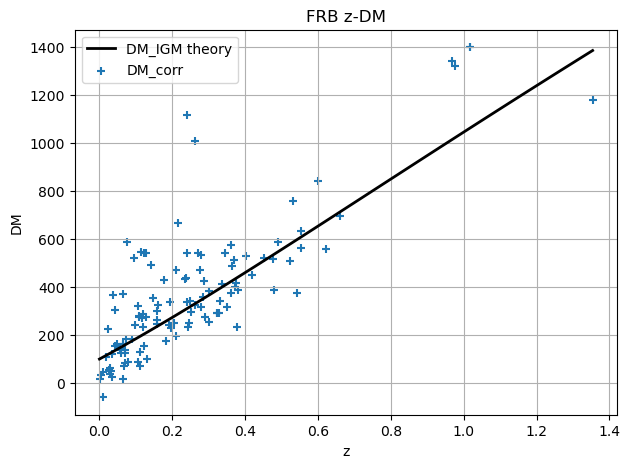

In [17]:
fig = plt.figure(figsize=(7,5))
ax1 = fig.add_subplot(111)

z_range = np.linspace(0, np.max(data['z']), 100)

DM_theory = np.zeros_like(z_range)
for idx, redshift in enumerate(z_range):
    DM_theory[idx] = dispersion_measure(redshift, H0=HUBBLE, Om=OMEGA_MATTER, w=-1, alpha=0.11, f_IGM_0 = f_IGM)

ax1.plot(z_range, 100+DM_theory, lw=2, c='black', label='DM_IGM theory')
ax1.scatter(data['z'], data['DM_ext(ne2001)'], s=40, marker='+', label='DM_corr')  
ax1.set_xlabel('z')
ax1.set_ylabel('DM')
ax1.set_title('FRB z-DM')
ax1.grid(True)
ax1.legend()


plt.show()

# Preparation

search F range 

In [6]:
load_arrays=np.load('./interpolation/068_C0median.npz')
Sigmas=load_arrays['a']
Errors=load_arrays['d']
C0s=load_arrays['c']
As=load_arrays['b']

In [7]:
sigma_error_inter= interpolate.interp1d(Errors, Sigmas, kind=1,bounds_error=False, 
    # fill_value='extrapolate'
    )

In [8]:
C0_sigma_inter = interpolate.interp1d(Sigmas, C0s, kind=1,bounds_error=False, 
    # fill_value='extrapolate'
    )

In [9]:
A_sigma_inter = interpolate.interp1d(Sigmas, As, kind=1,bounds_error=False, 
    # fill_value='extrapolate'
    )

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


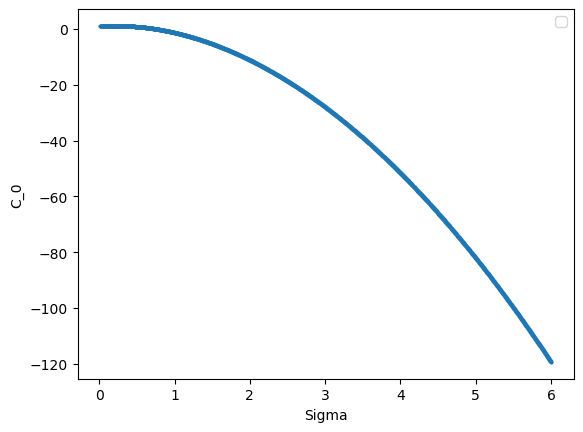

In [10]:
plt.scatter(Sigmas, C0s,  s=3)

plt.ylabel('C_0')
plt.xlabel('Sigma')
plt.legend()

plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


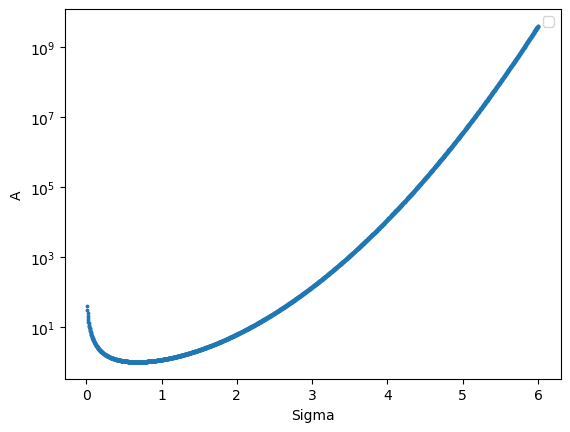

In [11]:
plt.scatter(Sigmas, As,  s=3)

plt.ylabel('A')
plt.xlabel('Sigma')
plt.yscale('log')
plt.legend()

plt.show()

plot

In [12]:
print(len(data))
# data = data[data['FRB'] != 'FRB 20190520B']
# data = data[data['FRB'] != 'FRB 20220831A']
# data = data[data['z'] >= 0.2]
# data = data[data['FRB'] == 'FRB 20230521B']
print(len(data))
data.head()

117
117


,FRB,z,gl,gb,DM,"DM_MW, ISM(NE2001)","DM_MW, ISM(YMW16)",DM_ext(ne2001),DM_ext(ymw16),Ref.
0,FRB 20180814A,0.06800,136.460000,16.580000,190.900,87.83,108.41,73.073904,52.493323,https://www.nature.com/articles/s41586-018-0864-x
1,FRB 20181030A,0.00385,133.400000,40.900000,103.396,40.35,32.24,33.045498,41.152729,https://iopscience.iop.org/article/10.3847/204...
2,FRB 20220529A,0.18390,130.787670,-41.858020,246.000,39.95,30.92,176.048832,185.076405,https://arxiv.org/abs/2503.04727
3,FRB 20220610A,1.01600,8.839200,-70.185700,1458.150,30.96,13.58,1397.192120,1414.571089,https://www.cambridge.org/core/journals/public...
4,FRB 20220717A,0.36295,19.835158,-17.632032,637.340,118.33,83.22,489.008396,524.116215,https://arxiv.org/pdf/2407.02173


In [13]:
drop_df = data.copy()

drop_df = drop_df[(drop_df['z'] < 0.3) | 
                    (drop_df['FRB'] == 'FRB 20190520B') | 
                    (drop_df['FRB'] == 'FRB 20220831A')]
print(len(drop_df))
drop_df.head()

81


,FRB,z,gl,gb,DM,"DM_MW, ISM(NE2001)","DM_MW, ISM(YMW16)",DM_ext(ne2001),DM_ext(ymw16),Ref.
0,FRB 20180814A,0.06800,136.46000,16.58000,190.900,87.83,108.41,73.073904,52.493323,https://www.nature.com/articles/s41586-018-0864-x
1,FRB 20181030A,0.00385,133.40000,40.90000,103.396,40.35,32.24,33.045498,41.152729,https://iopscience.iop.org/article/10.3847/204...
2,FRB 20220529A,0.18390,130.78767,-41.85802,246.000,39.95,30.92,176.048832,185.076405,https://arxiv.org/abs/2503.04727
5,FRB 20220831A,0.26200,110.96000,12.47000,1146.250,110.21,147.77,1006.037178,968.481598,https://arxiv.org/pdf/2409.16952
11,FRB 20240213A,0.11850,136.49000,41.57000,357.400,40.10,31.76,287.300108,295.642361,https://arxiv.org/pdf/2409.16952


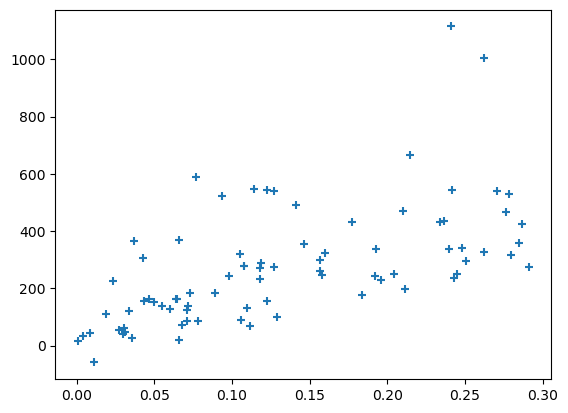

In [14]:
plt.scatter(drop_df['z'], drop_df['DM_ext(ne2001)'], s=40, marker='+', label='DM_corr')

In [33]:
""" def DM_IGM_H0_O_b_f_IGM_fast(z, H0_O_b_f_IGM, Om=OMEGA_MATTER, w=-1):
    
    def integrand(z):
        return (1+z)/np.sqrt(Om*(1+z)**3+(1-Om)*(1+z)**(3*(1+w)))

    factor = 3*C_LIGHT*H0_O_b_f_IGM/(8*PI*G_NEWTON*M_PROTON)*(7/8)
    
    zs=np.linspace(0, z, 5000)
    dms=integrand(zs)
    integral=np.trapz(dms, x=zs)
    
    unit_transform = DM_2_PCCM3*KM_2_MPC
    
    DM = unit_transform*factor*integral
    
    return DM """

' def DM_IGM_H0_O_b_f_IGM_fast(z, H0_O_b_f_IGM, Om=OMEGA_MATTER, w=-1):\n    \n    def integrand(z):\n        return (1+z)/np.sqrt(Om*(1+z)**3+(1-Om)*(1+z)**(3*(1+w)))\n\n    factor = 3*C_LIGHT*H0_O_b_f_IGM/(8*PI*G_NEWTON*M_PROTON)*(7/8)\n    \n    zs=np.linspace(0, z, 5000)\n    dms=integrand(zs)\n    integral=np.trapz(dms, x=zs)\n    \n    unit_transform = DM_2_PCCM3*KM_2_MPC\n    \n    DM = unit_transform*factor*integral\n    \n    return DM '

In [34]:
""" def calculate_dm_probability_num_HOf_fast(DM_frb_max, z, F, HOf, e_mu, sigma_host):
    
    ## Cosmic calculation    
    DM_th = DM_IGM_H0_O_b_f_IGM_fast(z=z, H0_O_b_f_IGM=HOf, Om=OMEGA_MATTER, w=-1)
    
    Delta_array = np.linspace(0, DM_frb_max / DM_th, 5000)
    
    sigma=sigma_var(np.sqrt(f_variance_delta(F,z)))
    
    C_0=C0_sigma(sigma)
    A = A_sigma(sigma)
    
    pdf_cosmic = pdf_DM_cosmo(Delta_array, C_0, A=A, sigma=sigma)
    
    ## Host calculation
    pdf_host = pdf_DM_host((1+z)*(DM_frb_max-DM_th * Delta_array), e_mu, sigma_host)
    
    ## Combine together    
    prob = np.trapz(pdf_host*pdf_cosmic, x=Delta_array)
    
    ## Transform to probabilities
    # dDM = np.abs(np.diff(DM_frb_array)[0])/DM_IGM_O_bh_70(z=z, O_bh_70=O_bh_70, Om=OMEGA_MATTER, w=-1,alpha=0)/(1+z)
    
    return prob*(1+z) """

' def calculate_dm_probability_num_HOf_fast(DM_frb_max, z, F, HOf, e_mu, sigma_host):\n    \n    ## Cosmic calculation    \n    DM_th = DM_IGM_H0_O_b_f_IGM_fast(z=z, H0_O_b_f_IGM=HOf, Om=OMEGA_MATTER, w=-1)\n    \n    Delta_array = np.linspace(0, DM_frb_max / DM_th, 5000)\n    \n    sigma=sigma_var(np.sqrt(f_variance_delta(F,z)))\n    \n    C_0=C0_sigma(sigma)\n    A = A_sigma(sigma)\n    \n    pdf_cosmic = pdf_DM_cosmo(Delta_array, C_0, A=A, sigma=sigma)\n    \n    ## Host calculation\n    pdf_host = pdf_DM_host((1+z)*(DM_frb_max-DM_th * Delta_array), e_mu, sigma_host)\n    \n    ## Combine together    \n    prob = np.trapz(pdf_host*pdf_cosmic, x=Delta_array)\n    \n    ## Transform to probabilities\n    # dDM = np.abs(np.diff(DM_frb_array)[0])/DM_IGM_O_bh_70(z=z, O_bh_70=O_bh_70, Om=OMEGA_MATTER, w=-1,alpha=0)/(1+z)\n    \n    return prob*(1+z) '

In [35]:
""" S=0.025
HOf=2.774
e_mu=96.468
sigma_host=0.750 """

' S=0.025\nHOf=2.774\ne_mu=96.468\nsigma_host=0.750 '

In [15]:
S=0.025
HOf=2.744
e_mu=96.154
sigma_host=0.754

In [19]:
z_range = np.linspace(0.3, 1.5, 500)
y_high = np.zeros_like(z_range)
y_low = np.zeros_like(z_range)

DM_linear = slope*z_range+intercept

DM_theory = np.zeros_like(z_range)

## The range of DM_cosmic (the y-axis)
DM_cosmic_range = np.linspace(0.01, 5000, 10000)

target_prob=0.90 # 0.9545 # 0.6827
for idx, z in tqdm(enumerate(z_range), total=len(z_range)):
    
    """ sigma=sigma_var(np.sqrt(f_variance_delta(F=16, z=z)))
    C0 = C0_sigma(sigma)
    A = A_sigma(sigma)#find_A_sigma(C_0=C0, sigma=sigma, alpha=3, beta=3) """
    DM_theory[idx] = dispersion_measure(z, H0=HUBBLE, Om=OMEGA_MATTER, w=-1, alpha=0, f_IGM_0 = f_IGM)
    
    ## The range of DM_cosmic (the y-axis)
    # DM_cosmic_range = np.linspace(0.01, np.max(data['DM_ext'])/(DM_theory[idx]), 1000)
    p = [calculate_dm_probability_num_HOf_fast(dm, z=z, 
                                               S=S, HOf=HOf, e_mu=e_mu, sigma_host=sigma_host,
                                               f_sigma_error=sigma_error_inter,f_C0_sigma=C0_sigma_inter,f_A_sigma=A_sigma_inter
                                               ) 
         for dm in DM_cosmic_range]
    # print(p)
    p = np.array(p)
    index=~np.isnan(p)
    p = p[index]
    p_DM=interpolate.interp1d(DM_cosmic_range[index], p, kind=1,bounds_error=False, 
        # fill_value='extrapolate'
    )
    p=p_DM(DM_cosmic_range)
    # pdf_DM_cosmo(DM_cosmic_range/(100+DM_theory[idx]), C_0=C0, A=A, sigma=sigma)
    
    ## Calculating the 5% and 95% limits, to plot the shaded area
    p=normalise(p)
    cdf = np.cumsum(p)
    lower_percentile = 0.5-target_prob/2  # 16%
    upper_percentile = 0.5+target_prob/2  # 84%
    lower_idx = np.searchsorted(cdf, lower_percentile)
    upper_idx = np.searchsorted(cdf, upper_percentile)
    y_low[idx] = DM_cosmic_range[lower_idx]
    y_high[idx] = DM_cosmic_range[upper_idx]

100%|██████████| 500/500 [21:27<00:00,  2.58s/it]


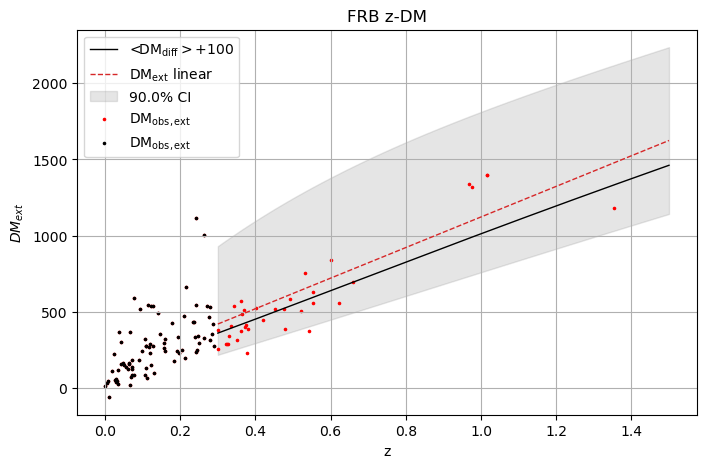

In [21]:
fig = plt.figure(figsize=(8, 5))
ax1 = fig.add_subplot(111)

ax1.plot(z_range, 100+DM_theory, lw=1, c='black', label=r'<DM$_{\rm diff}>$+100')
ax1.plot(z_range, DM_linear, lw=1, ls='--', c='tab:red', label=r'DM$_{\rm ext}$ linear')
ax1.fill_between(z_range, y_low, y_high, alpha=0.2, color='grey', label=f'{100*target_prob}% CI')

ax1.scatter(data['z'], data['DM_ext(ne2001)'], s=10, marker='.', label=r'DM$_{\rm obs, ext}$', color='red') 
ax1.scatter(drop_df['z'], drop_df['DM_ext(ne2001)'], s=10, marker='.', label=r'DM$_{\rm obs, ext}$',color='black')  

ax1.set_xlabel('z')
ax1.set_ylabel(r'$DM_{ext}$')
ax1.set_title('FRB z-DM')
ax1.grid(True)
ax1.legend()

plt.savefig('./plot/DM_ext_z.pdf', dpi=300, bbox_inches='tight')
plt.show()

For test

In [64]:
p = calculate_dm_probability_num_HOf_fast(600, z=1.0, F=F, HOf=HOf, e_mu=e_mu, sigma_host=sigma_host)
print(p)

1.1304591430542493e-12


/mnt/d/Document/Research/FRB/cosmology/FRB_cosmology/code/../Python_scripts/cosmo_support.py:376: RuntimeWarning: invalid value encountered in log
  np.exp(-(np.log(non_zero_DM)-mu)**2/(2*(sigma_host**2)))


[  30.03470735   63.05088544  118.07784892  121.07931966  124.0807904
  234.13471736  235.1352076   238.13667834  241.13814907  244.13961981
  247.14109055  471.25090545  477.25384692  483.25678839  485.25776888
  491.26071036  497.26365183  502.26610305  503.2665933   508.26904452
  509.26953477  939.48034017  940.48083042  942.48181091  951.48622311
  952.48671336  954.48769385  955.48818409  964.4925963   966.49357679
  967.49406703  976.49847924  979.49994997  988.50436218  989.50485243
  991.50583292 1001.51073537 1003.51171586 1004.5122061  1013.51661831
 1016.51808904 1872.93773887 1874.93871936 1878.94068034 1880.94166083
 1883.94313157 1887.94509255 1889.94607304 1898.95048524 1902.95244622
 1904.95342671 1907.95489745 1913.95783892 1922.96225113 1928.9651926
 1931.96666333 1933.96764382 1937.9696048  1943.97254627 1946.97401701
 1948.9749975  1952.97695848 1957.9794097  1961.98137069 1963.98235118
 1967.98431216 1972.98676338 1976.98872436 1978.98970485 1987.99411706
 1991.99

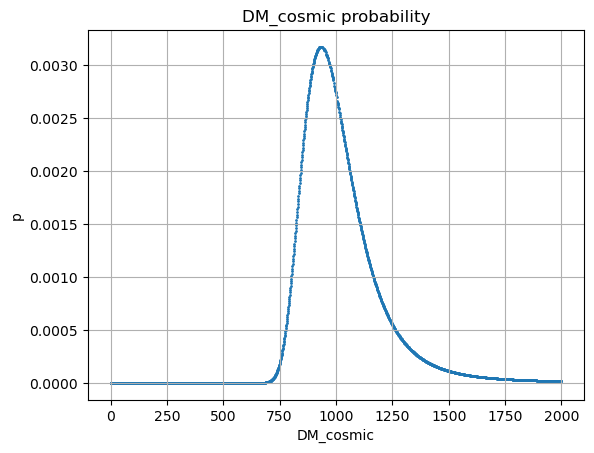

In [70]:
z=1.3
p = [calculate_dm_probability_num_HOf_fast(DM, z=1.0, F=F, HOf=HOf, e_mu=e_mu, sigma_host=sigma_host) for DM in DM_cosmic_range]
p = np.array(p)
print(DM_cosmic_range[np.isnan(p)])
# index=~np.isnan(p)
# p = p[index]
# DM_cosmic_range = DM_cosmic_range[index]
print(len(p))
print(len(DM_cosmic_range))
plt.scatter(DM_cosmic_range, p, s=1)
plt.ylabel('p')
plt.xlabel('DM_cosmic')
plt.title('DM_cosmic probability')
plt.grid()
plt.show()

In [55]:
cdf = np.cumsum(p)
y_high[idx] = DM_cosmic_range[np.argmin(np.abs(cdf-0.95))]
y_low[idx] = DM_cosmic_range[np.argmin(np.abs(cdf-0.05))]